In [ ]:
%reload_ext autoreload
from functions_v2 import *

In [ ]:
import networkx as nx
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
from scipy.sparse import coo_matrix

In [ ]:
edges, n_vertices, edge_weights = load_graph("../summer-project/oregon1_010526.txt")

In [ ]:
edges, n_vertices, edge_weights = load_graph("oregon1_010526.txt")

# remap node IDs to contiguous 0-indexed
all_nodes = sorted(set(v for e in edges for v in e))
node_map  = {old: new for new, old in enumerate(all_nodes)}
edges     = [(node_map[i], node_map[j]) for (i,j) in edges]
n_vertices = len(all_nodes)

print(f"Remapped vertices: {n_vertices}")  # should be 11174
print(f"Edges: {len(edges)}")              # should be 23409

In [ ]:
# check if it is connected
G_nx = nx.Graph()
G_nx.add_edges_from(edges)
num_components = nx.number_connected_components(G_nx)
component_sizes = sorted([len(c) for c in nx.connected_components(G_nx)], reverse=True)
print(f"Connected components: {num_components}")
print(f"Component sizes: {component_sizes[:10]}")  # show top 10 in case there are many

In [ ]:
A, D, L = build_graph_matrices(edges, n_vertices, edge_weights)

In [ ]:
lambda_min = compute_lambda_min(L, D)

In [ ]:
L_sigma  = build_shifted_laplacian(L, D, lambda_min, sigma_squared=0.25)

In [ ]:
all_nodes = set(v for e in edges for v in e)
print(f"min: {min(all_nodes)}, max: {max(all_nodes)}, count: {len(all_nodes)}, n_vertices: {n_vertices}")

In [ ]:
def find_diameter_endpoints(G_nx, n_sample=5, k_hop=4):
    best_dist = 0
    best_v, best_w = None, None
    start_nodes = list(G_nx.nodes())[:n_sample]

    for start in start_nodes:
        lengths = nx.single_source_shortest_path_length(G_nx, start)
        v = max(lengths, key=lengths.get)
        lengths_v = nx.single_source_shortest_path_length(G_nx, v)
        w = max(lengths_v, key=lengths_v.get)
        dist = lengths_v[w]
        if dist > best_dist:
            best_dist = dist
            best_v, best_w = v, w

    gamma_in  = set(nx.single_source_shortest_path_length(G_nx, best_v, cutoff=k_hop).keys())
    gamma_out = set(nx.single_source_shortest_path_length(G_nx, best_w, cutoff=k_hop).keys())
    gamma_in  = gamma_in - gamma_out
    gamma_out = gamma_out - gamma_in
    gamma_in  = list(map(int, gamma_in))
    gamma_out = list(map(int, gamma_out))

    print(f"✓ Diameter endpoints: vertex {best_v} and vertex {best_w}")
    print(f"  Shortest path: {best_dist} hops")
    print(f"  gamma_in: {len(gamma_in)} vertices")
    print(f"  gamma_out: {len(gamma_out)} vertices")
    return gamma_in, gamma_out, best_dist

gamma_in, gamma_out, diameter = find_diameter_endpoints(G_nx, n_sample=5, k_hop=4)

# sanity checks
overlap = set(gamma_in) & set(gamma_out)
assert len(overlap) == 0, f"Overlap found: {overlap}"
max_id = max(max(gamma_in), max(gamma_out))
assert max_id < n_vertices, "gamma contains out-of-range node ID"
print("✓ gamma_in/gamma_out validated")

In [ ]:
B = build_incidence_matrix(edges, n_vertices)
cho_cache = cho_factor(L_sigma)
w = np.random.randn(len(edges))
f = B @ w
u = cho_solve(cho_cache, np.sqrt(lambda_min) * f)

k = compute_permeability(u, edges, edge_weights)
L_k = build_weighted_laplacian(edges, n_vertices, k)
p = solve_darcy(L_k, n_vertices, gamma_in, gamma_out, debug=True)
Q = extract_qoi(p, k, edges, gamma_out)
print(f"Single-sample Q: {Q}")

In [ ]:
from scipy.sparse.linalg import splu
from scipy.sparse import csc_matrix, diags

def build_shifted_laplacian_sparse(L, D, lambda_min, sigma_squared=0.25):
    """
    Sparse version of build_shifted_laplacian — keeps L_sigma sparse
    instead of converting to dense, for use with splu-based factorization
    in Phase 3 (faster for large graphs like Oregon Router).

    Parameters
    ----------
    L, D        : sparse matrices (from build_graph_matrices)
    lambda_min  : float
    sigma_squared : float, default 0.25

    Returns
    -------
    L_sigma_sparse : scipy.sparse.csc_matrix — shifted Laplacian, sparse
    """
    L_sigma_sparse = (L + sigma_squared * lambda_min * D).tocsc()
    return L_sigma_sparse


def run_phase3_sparse(L_sigma_sparse, lambda_min, edges, n_vertices):
    """
    Sparse version of run_phase3 — uses splu instead of dense Cholesky.

    Steps (same as run_phase3):
        3a. Draw edge noise:       w_e ~ N(0,1) for every edge
        3b. Map noise to vertices: f = B @ w
        3c. Solve for u:           L_sigma @ u = sqrt(lambda_min) * f

    L_sigma_sparse is LU-factorized once here for reuse in the MC loop.

    Returns
    -------
    u   : np.ndarray (n_vertices,) — spatially correlated field
    B   : sparse incidence matrix (reuse in MC loop)
    lu  : splu factorization object (reuse in MC loop, replaces cho_cache)
    """
    B  = build_incidence_matrix(edges, n_vertices)
    lu = splu(L_sigma_sparse)

    w = np.random.randn(len(edges))
    f = B @ w
    u = lu.solve(np.sqrt(lambda_min) * f)

    print("✓ Phase 3 (sparse) complete: correlated field u generated")
    print(f"  u range: [{u.min():.4f}, {u.max():.4f}]")
    print()
    return u, B, lu


def monte_carlo_loop_sparse(L_sigma_sparse, lambda_min, edges, n_vertices,
                              gamma_in, gamma_out, edge_weights=None,
                              N=1000, debug=True):
    """
    Sparse-Cholesky (splu) version of monte_carlo_loop_tqdm — identical
    structure and hardened checks, but uses splu instead of dense
    cho_factor/cho_solve for Phase 3, targeting the dense-Cholesky
    bottleneck on large graphs (e.g. Oregon Router).
    """
    B  = build_incidence_matrix(edges, n_vertices)
    lu = splu(L_sigma_sparse)  # one-time sparse LU factorization, reused every sample

    Q_samples = np.zeros(N)
    edges_arr = np.array(edges)
    i_arr     = edges_arr[:, 0]
    j_arr     = edges_arr[:, 1]
    row_idx = np.concatenate([i_arr, j_arr, i_arr, j_arr])
    col_idx = np.concatenate([i_arr, j_arr, j_arr, i_arr])

    boundary   = set(gamma_in) | set(gamma_out)
    interior   = np.array([v for v in range(n_vertices) if v not in boundary])
    p_boundary = np.zeros(n_vertices)
    for v in gamma_in:
        p_boundary[v] = 1.0
    for v in gamma_out:
        p_boundary[v] = 0.0
    gamma_out_set = set(gamma_out)

    with tqdm(total=N, desc="Monte Carlo (sparse)", unit="sample") as pbar:
        for idx in range(N):
            # Phase 3 — sparse solve replaces cho_solve
            w = np.random.randn(len(edges))
            f = B @ w
            u = lu.solve(np.sqrt(lambda_min) * f)

            # Phase 4 — unchanged
            k_vals = np.exp((u[i_arr] + u[j_arr]) / 2)

            # Phase 5a — unchanged
            diag_data = np.concatenate([k_vals, k_vals])
            offdiag_data = np.concatenate([-k_vals, -k_vals])
            data = np.concatenate([diag_data, offdiag_data])
            L_k  = coo_matrix((data, (row_idx, col_idx)),
                               shape=(n_vertices, n_vertices)).tocsr()

            # Phase 5b — unchanged, hardened
            L_interior = L_k[interior, :][:, interior]
            rhs        = -L_k[interior, :][:, list(boundary)] @ p_boundary[list(boundary)]
            p_interior = spsolve(L_interior, rhs)

            if debug:
                if np.any(np.isnan(p_interior)) or np.any(np.isinf(p_interior)):
                    raise ValueError(
                        f"Sample {idx}: solve produced NaN/Inf in interior pressures."
                    )

            p = np.zeros(n_vertices)
            p[interior] = p_interior
            for v in gamma_in:
                p[v] = 1.0
            for v in gamma_out:
                p[v] = 0.0

            if debug:
                tol = 1e-8
                if p[interior].min() < -tol or p[interior].max() > 1 + tol:
                    raise ValueError(
                        f"Sample {idx}: pressure out of physical bounds "
                        f"[min={p[interior].min():.6f}, max={p[interior].max():.6f}]."
                    )

            # Phase 6 — unchanged
            p_diff = np.abs(p[i_arr] - p[j_arr])
            outlet_mask = np.array([i in gamma_out_set or j in gamma_out_set
                                    for i,j in edges])
            Q_samples[idx] = np.sum(k_vals[outlet_mask] * p_diff[outlet_mask])
            pbar.update(1)
            pbar.set_postfix({"mean Q": f"{Q_samples[:idx+1].mean():.4f}"})

    print(f"\n✓ Done (sparse) — {N} samples")
    print(f"  Mean Q : {Q_samples.mean():.6f}")
    print(f"  Std Q  : {Q_samples.std():.6f}")
    return Q_samples

In [ ]:
def compare_dense_vs_sparse_cholesky(L_sigma, lambda_min, B, edges, N_test=10):
    """
    Compare dense Cholesky (current pipeline) vs sparse splu for the
    L_sigma factorization + repeated solves in Phase 3.
    """
    if hasattr(L_sigma, 'toarray'):
        L_sigma_sparse = L_sigma.tocsc()
        L_sigma_dense = L_sigma.toarray()
    else:
        L_sigma_dense = L_sigma
        L_sigma_sparse = csc_matrix(L_sigma)

    print(f"L_sigma shape: {L_sigma_dense.shape}")

    print("\nFactorizing: dense Cholesky...")
    t0 = time.time()
    cho_cache = cho_factor(L_sigma_dense)
    dense_setup_time = time.time() - t0
    print(f"  Dense setup: {dense_setup_time:.3f}s")

    print("Factorizing: sparse splu...")
    t0 = time.time()
    lu = splu(L_sigma_sparse)
    sparse_setup_time = time.time() - t0
    print(f"  Sparse setup: {sparse_setup_time:.3f}s")

    dense_solve_times = []
    sparse_solve_times = []
    max_diffs = []

    for trial in range(N_test):
        w = np.random.randn(len(edges))
        f = B @ w
        rhs = np.sqrt(lambda_min) * f

        t0 = time.time()
        u_dense = cho_solve(cho_cache, rhs)
        dense_solve_times.append(time.time() - t0)

        t0 = time.time()
        u_sparse = lu.solve(rhs)
        sparse_solve_times.append(time.time() - t0)

        diff = np.max(np.abs(u_dense - u_sparse))
        max_diffs.append(diff)

    dense_solve_times = np.array(dense_solve_times)
    sparse_solve_times = np.array(sparse_solve_times)

    print(f"\n--- Per-sample solve timing (N={N_test}) ---")
    print(f"Dense  solve: mean={dense_solve_times.mean():.4f}s, std={dense_solve_times.std():.4f}s")
    print(f"Sparse solve: mean={sparse_solve_times.mean():.4f}s, std={sparse_solve_times.std():.4f}s")
    print(f"Max solution difference: {max(max_diffs):.2e}")

    N_full = 500
    dense_total = dense_setup_time + dense_solve_times.mean() * N_full
    sparse_total = sparse_setup_time + sparse_solve_times.mean() * N_full

    print(f"\n--- Extrapolated total time for N={N_full} samples ---")
    print(f"Dense  (setup + {N_full} solves): {dense_total:.1f}s ({dense_total/60:.1f} min)")
    print(f"Sparse (setup + {N_full} solves): {sparse_total:.1f}s ({sparse_total/60:.1f} min)")
    print(f"Sparse is {'FASTER' if sparse_total < dense_total else 'SLOWER'} "
          f"by {abs(dense_total - sparse_total):.1f}s "
          f"({abs(dense_total - sparse_total) / max(dense_total, sparse_total) * 100:.1f}%)")

    return {
        'dense_setup_time': dense_setup_time,
        'sparse_setup_time': sparse_setup_time,
        'dense_solve_times': dense_solve_times,
        'sparse_solve_times': sparse_solve_times,
        'max_diff': max(max_diffs),
    }

In [ ]:
# 1. Build sparse L_sigma (instead of your existing dense build_shifted_laplacian)
L_sigma_sparse = build_shifted_laplacian_sparse(L, D, lambda_min)

# 2. Run the comparison script from before to confirm sparse actually wins on YOUR Oregon data
B = build_incidence_matrix(edges, n_vertices)
results = compare_dense_vs_sparse_cholesky(L_sigma, lambda_min, B, edges, N_test=10)
# (pass your existing dense L_sigma here — the function builds the sparse version internally too)

In [ ]:
# 1. Build sparse L_sigma (instead of your existing dense build_shifted_laplacian)
L_sigma_sparse = build_shifted_laplacian_sparse(L, D, lambda_min)

# 2. Run the comparison script from before to confirm sparse actually wins on YOUR Oregon data
B = build_incidence_matrix(edges, n_vertices)
results = compare_dense_vs_sparse_cholesky(L_sigma, lambda_min, B, edges, N_test=10)
# (pass your existing dense L_sigma here — the function builds the sparse version internally too)

# 3. If sparse wins for N=500 extrapolation, run the full sparse pipeline:
Q_samples = monte_carlo_loop_sparse(
    L_sigma_sparse, lambda_min, edges, n_vertices,
    gamma_in, gamma_out, edge_weights,
    N=500, debug=True
)

In [ ]:
analyze_qoi(Q_samples)

In [ ]:
Q_samples = monte_carlo_loop_sparse(
    L_sigma_sparse, lambda_min, edges, n_vertices,
    gamma_in, gamma_out, edge_weights,
    N=300, debug=True
)

## Use sparse cholesky

In [ ]:
pip install scikit-sparse==0.4.16 --break-system-packages

In [ ]:
import sys
print(sys.executable)

from sksparse.cholmod import cholesky
print("scikit-sparse import: ok")

In [ ]:
import numpy as np
import networkx as nx
from functions_v2 import *

# Load
edges, n_vertices, edge_weights = load_graph("../summer-project/data/raw/oregon1_010526.txt")

G_nx = nx.Graph()
G_nx.add_edges_from(edges)
print("Components:", nx.number_connected_components(G_nx))

In [ ]:
# phase 1
# Phase 1
A, D, L = build_graph_matrices(edges, n_vertices, edge_weights)

In [ ]:
# Phase 2
lambda_min = compute_lambda_min(L, D)
L_sigma = build_shifted_laplacian(L, D, lambda_min)  # current dense version

In [ ]:
degrees = np.array(A.sum(axis=1)).flatten()
print(f"Number of vertices with degree 0: {np.sum(degrees == 0)}")
print(f"Min degree: {degrees.min()}, Max degree: {degrees.max()}")

all_nodes_in_edges = set(v for e in edges for v in e)
print(f"n_vertices: {n_vertices}")
print(f"Actual distinct nodes referenced in edges: {len(all_nodes_in_edges)}")
print(f"max node id in edges: {max(all_nodes_in_edges)}")

In [ ]:
all_nodes = sorted(set(v for e in edges for v in e))
node_map = {old: new for new, old in enumerate(all_nodes)}
edges = [(node_map[i], node_map[j]) for (i, j) in edges]
n_vertices = len(all_nodes)

print(f"Remapped n_vertices: {n_vertices}")

In [ ]:
# Phase 1
A, D, L = build_graph_matrices(edges, n_vertices, edge_weights)

In [ ]:
# Phase 2
lambda_min = compute_lambda_min(L, D)
L_sigma = build_shifted_laplacian(L, D, lambda_min)  # current dense version

In [ ]:
# Diameter-endpoint gamma
def find_diameter_endpoints(G_nx, n_sample=5, k_hop=4):
    best_dist = 0
    best_v, best_w = None, None
    start_nodes = list(G_nx.nodes())[:n_sample]
    for start in start_nodes:
        lengths = nx.single_source_shortest_path_length(G_nx, start)
        v = max(lengths, key=lengths.get)
        lengths_v = nx.single_source_shortest_path_length(G_nx, v)
        w = max(lengths_v, key=lengths_v.get)
        dist = lengths_v[w]
        if dist > best_dist:
            best_dist = dist
            best_v, best_w = v, w
    gamma_in  = set(nx.single_source_shortest_path_length(G_nx, best_v, cutoff=k_hop).keys())
    gamma_out = set(nx.single_source_shortest_path_length(G_nx, best_w, cutoff=k_hop).keys())
    gamma_in  = gamma_in - gamma_out
    gamma_out = gamma_out - gamma_in
    return list(map(int, gamma_in)), list(map(int, gamma_out)), best_dist

gamma_in, gamma_out, diameter = find_diameter_endpoints(G_nx, n_sample=5, k_hop=4)
print(f"gamma_in: {len(gamma_in)}, gamma_out: {len(gamma_out)}")

# Incidence matrix
B = build_incidence_matrix(edges, n_vertices)

In [ ]:
import time
from scipy.linalg import cho_factor, cho_solve
from sksparse.cholmod import cholesky as sparse_cholesky

def compare_dense_vs_sparse_cholesky(L_sigma, lambda_min, B, edges, N_test=10):
    if hasattr(L_sigma, 'toarray'):
        L_sigma_sparse = L_sigma.tocsc()
        L_sigma_dense = L_sigma.toarray()
    else:
        L_sigma_dense = L_sigma
        from scipy.sparse import csc_matrix
        L_sigma_sparse = csc_matrix(L_sigma)

    print(f"L_sigma shape: {L_sigma_dense.shape}")

    print("\nFactorizing: dense Cholesky (current pipeline)...")
    t0 = time.time()
    cho_cache = cho_factor(L_sigma_dense)
    dense_setup_time = time.time() - t0
    print(f"  Dense setup: {dense_setup_time:.3f}s")

    print("Factorizing: sparse Cholesky (scikit-sparse/CHOLMOD)...")
    t0 = time.time()
    factor = sparse_cholesky(L_sigma_sparse)
    sparse_setup_time = time.time() - t0
    print(f"  Sparse setup: {sparse_setup_time:.3f}s")

    dense_solve_times = []
    sparse_solve_times = []
    max_diffs = []

    for trial in range(N_test):
        w = np.random.randn(len(edges))
        f = B @ w
        rhs = np.sqrt(lambda_min) * f

        t0 = time.time()
        u_dense = cho_solve(cho_cache, rhs)
        dense_solve_times.append(time.time() - t0)

        t0 = time.time()
        u_sparse = factor.solve_A(rhs)
        sparse_solve_times.append(time.time() - t0)

        diff = np.max(np.abs(u_dense - u_sparse))
        max_diffs.append(diff)

    dense_solve_times = np.array(dense_solve_times)
    sparse_solve_times = np.array(sparse_solve_times)

    print(f"\n--- Per-sample solve timing (N={N_test}) ---")
    print(f"Dense  Cholesky solve: mean={dense_solve_times.mean():.5f}s")
    print(f"Sparse Cholesky solve: mean={sparse_solve_times.mean():.5f}s")
    print(f"Max solution difference: {max(max_diffs):.2e}")

    N_full = 500
    dense_total = dense_setup_time + dense_solve_times.mean() * N_full
    sparse_total = sparse_setup_time + sparse_solve_times.mean() * N_full
    print(f"\n--- Extrapolated total time for N={N_full} samples ---")
    print(f"Dense  total: {dense_total:.1f}s ({dense_total/60:.1f} min)")
    print(f"Sparse total: {sparse_total:.1f}s ({sparse_total/60:.1f} min)")

    return dense_solve_times, sparse_solve_times

compare_dense_vs_sparse_cholesky(L_sigma, lambda_min, B, edges, N_test=10)

# Testing the new pipeline with sparse cholesky solve

In [2]:
import numpy as np
import networkx as nx
from functions_v2 import *

# Load
edges, n_vertices, edge_weights = load_graph("../summer-project/data/raw/oregon1_010526.txt")

G_nx = nx.Graph()
G_nx.add_edges_from(edges)
print("Components:", nx.number_connected_components(G_nx))

✓ Loaded: ../summer-project/data/raw/oregon1_010526.txt
  Vertices : 65502
  Edges    : 23409
  Weighted : no

Components: 1


In [4]:
# 2. Remap — Oregon's node IDs are non-contiguous (this was the earlier bug)
all_nodes = sorted(set(v for e in edges for v in e))
node_map = {old: new for new, old in enumerate(all_nodes)}
edges = [(node_map[i], node_map[j]) for (i, j) in edges]
n_vertices = len(all_nodes)
print(f"Remapped: n_vertices={n_vertices}, edges={len(edges)}")

Remapped: n_vertices=11174, edges=23409


In [6]:
# 3. Confirm connectivity
G_nx = nx.Graph()
G_nx.add_edges_from(edges)
print("Components:", nx.number_connected_components(G_nx))

Components: 1


In [8]:
# 4. Phase 1
A, D, L = build_graph_matrices(edges, n_vertices, edge_weights)

✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 11174 x 11174
  Degree range: [1, 2389]
  Non-zeros in L: 57992



In [10]:
# 5. Phase 2 — sparse L_sigma
lambda_min = compute_lambda_min(L, D)
L_sigma = build_shifted_laplacian(L, D, lambda_min)  # returns sparse now
print("L_sigma type:", type(L_sigma))

✓ lambda_min = 0.032899
  (eigenvalues found: [0.         0.03289937])
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)
  L_sigma type: sparse

L_sigma type: <class 'scipy.sparse._csr.csr_matrix'>


In [12]:
# 6. Gamma_in / gamma_out — diameter endpoints
def find_diameter_endpoints(G_nx, n_sample=5, k_hop=4):
    best_dist = 0
    best_v, best_w = None, None
    start_nodes = list(G_nx.nodes())[:n_sample]
    for start in start_nodes:
        lengths = nx.single_source_shortest_path_length(G_nx, start)
        v = max(lengths, key=lengths.get)
        lengths_v = nx.single_source_shortest_path_length(G_nx, v)
        w = max(lengths_v, key=lengths_v.get)
        dist = lengths_v[w]
        if dist > best_dist:
            best_dist = dist
            best_v, best_w = v, w
    gamma_in  = set(nx.single_source_shortest_path_length(G_nx, best_v, cutoff=k_hop).keys())
    gamma_out = set(nx.single_source_shortest_path_length(G_nx, best_w, cutoff=k_hop).keys())
    gamma_in  = gamma_in - gamma_out
    gamma_out = gamma_out - gamma_in
    return list(map(int, gamma_in)), list(map(int, gamma_out)), best_dist

In [14]:
gamma_in, gamma_out, diameter = find_diameter_endpoints(G_nx, n_sample=5, k_hop=4)
print(f"gamma_in: {len(gamma_in)}, gamma_out: {len(gamma_out)}, diameter: {diameter}")

gamma_in: 11, gamma_out: 92, diameter: 10


In [16]:
# sanity checks
overlap = set(gamma_in) & set(gamma_out)
assert len(overlap) == 0
assert max(max(gamma_in), max(gamma_out)) < n_vertices

In [18]:
Q_samples = monte_carlo_loop_tqdm(
    L_sigma, lambda_min, edges, n_vertices,
    gamma_in, gamma_out, edge_weights=None,
    N=500, debug=True
)

C:\Users\Rakesh\Documents\summer-project\functions_v2.py:658: CholmodTypeConversionWarning: converting matrix of class csr_matrix to CSC format
  factor = sparse_cholesky(L_sigma)   # L_sigma must be sparse (CSC) — see build_shifted_laplacian
Monte Carlo: 100%|███████████████████████████████████████████████| 500/500 [02:20<00:00,  3.57sample/s, mean Q=17.0526]


✓ Done — 500 samples
  Mean Q : 17.052594
  Std Q  : 0.352923



=== Monte Carlo Results ===
  Samples : 500
  Mean Q  : 17.052594
  Std Q   : 0.352923
  Var Q   : 0.124555
  Min Q   : 16.019996
  Max Q   : 18.103445


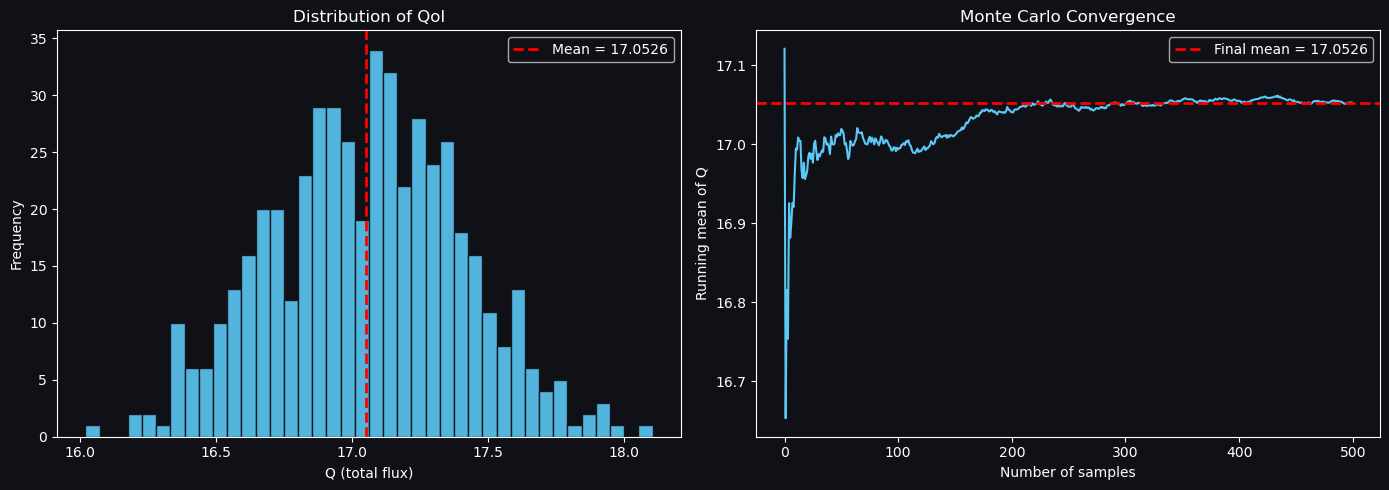

In [20]:
analyze_qoi(Q_samples)

In [22]:
import time

# time a few individual samples manually to see where time goes now
t0 = time.time()
w = np.random.randn(len(edges))
f = B @ w
u = factor.solve_A(np.sqrt(lambda_min) * f)
t1 = time.time()

k_vals = np.exp((u[i_arr] + u[j_arr]) / 2)
diag_data = np.concatenate([k_vals, k_vals])
offdiag_data = np.concatenate([-k_vals, -k_vals])
data = np.concatenate([diag_data, offdiag_data])
L_k = coo_matrix((data, (row_idx, col_idx)), shape=(n_vertices, n_vertices)).tocsr()
t2 = time.time()

L_interior = L_k[interior, :][:, interior]
rhs = -L_k[interior, :][:, list(boundary)] @ p_boundary[list(boundary)]
p_interior = spsolve(L_interior, rhs)
t3 = time.time()

print(f"Phase 3 (sparse Cholesky): {t1-t0:.4f}s")
print(f"Phase 4-5a (permeability + L_k build): {t2-t1:.4f}s")
print(f"Phase 5b (spsolve Darcy): {t3-t2:.4f}s")

NameError: name 'B' is not defined